#  Netflix Content Strategy Analysis — A Data-Driven Exploratory Study

**Dataset:** Netflix Titles (Kaggle)

**Tool:** Python — Pandas, Matplotlib, Seaborn


---

## Objective
To analyze Netflix’s content library using data-driven techniques in order to uncover insights into content distribution, global expansion, audience targeting, and strategic trends over time.

---

#  Business Questions

1. Is Netflix shifting from Movies to TV Shows over time?
2. How has Netflix expanded globally in terms of content?
3. What type of content dominates different regions?
4. What audience segment does Netflix primarily target?
5. Does Netflix prioritize quantity or engagement?

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Dataset

In [44]:
df=pd.read_csv('netflix_titles.csv',encoding='latin')
df = df.copy()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Initial Exploration

Getting the shape, columns, data types, and missing value overview
before making any changes to the data.

In [45]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))

Shape: (8809, 26)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   object 
 1   type          8809 non-null   object 
 2   title         8809 non-null   object 
 3   director      6175 non-null   object 
 4   cast          7984 non-null   object 
 5   country       7978 non-null   object 
 6   date_added    8799 non-null   object 
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   object 
 9   duration      8806 non-null   object 
 10  listed_in     8809 non-null   object 
 11  description   8809 non-null   object 
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null    

In [47]:
df.describe()

,release_year,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,8809.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2014.181292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,8.818932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1925.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2024.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
print('Duplicate rows:', df.duplicated().sum())
print()
print('Missing values per column:')
print(df.isnull().sum())

Duplicate rows: 0

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
Unnamed: 12     8809
Unnamed: 13     8809
Unnamed: 14     8809
Unnamed: 15     8809
Unnamed: 16     8809
Unnamed: 17     8809
Unnamed: 18     8809
Unnamed: 19     8809
Unnamed: 20     8809
Unnamed: 21     8809
Unnamed: 22     8809
Unnamed: 23     8809
Unnamed: 24     8809
Unnamed: 25     8809
dtype: int64


## 3. Data Cleaning & Preprocessing

### Observations from Initial Exploration:
- Dataset has **8,809 rows and 26 columns**
- Columns `Unnamed: 12` to `Unnamed: 25` are **completely empty** (ghost columns
  caused by extra commas in the CSV file) — these will be dropped
- `director` has **2,634 missing values (29.9%)** — filled with `'Unknown'`
  since these are proper names and cannot be imputed
- `cast` has **825 missing values** — filled with `'Unknown'`
- `country` has **831 missing values** — filled with mode (most frequent country)
- `date_added` has **10 missing values** — filled with mode after datetime conversion
- `rating` has **4 missing values** — filled with mode
- `duration` has **3 missing values** — handled separately during feature engineering
- **No duplicate rows** found

There are many empty columns


In [49]:
# Drop columns that are completely empty across all rows
df = df.dropna(axis=1, how='all')
print('Shape after dropping empty columns:', df.shape)
print('Remaining columns:', list(df.columns))

Shape after dropping empty columns: (8809, 12)
Remaining columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


Removed empty columns

In [50]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [51]:
# Director and cast filled with 'Unknown' — they are proper names,
# using mode would assign a real person's name to wrong titles
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')

# Country filled with mode — geographic value, mode is reasonable
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Rating filled with mode — only 4 missing rows
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

print('Missing values after filling:')
print(df[['director','cast','country','rating']].isnull().sum())

Missing values after filling:
director    0
cast        0
country     0
rating      0
dtype: int64


In [52]:
# removing hidden spaces
df['date_added'] = df['date_added'].str.strip()

#  convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# check missing values
df['date_added'].isna().sum()

# Filling missing values
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

## 4. Feature Engineering — Duration Column

The `duration` column contains **two different units mixed together:**
- Movies → `"90 min"`, `"111 min"`
- TV Shows → `"1 Season"`, `"2 Seasons"`

**Strategy:**
- Split into `duration_value` (numeric) and `duration_unit` (text)
- Fill 3 missing Movie durations with the **median movie duration**
- Standardize `'Season'` → `'Seasons'` for consistency
- Drop the original `duration` column

In [53]:
print(df[df['duration'].isna()][['type', 'duration']])

       type duration
5541  Movie      NaN
5794  Movie      NaN
5813  Movie      NaN


In [54]:
# Extract numeric value and unit separately
df['duration_value'] = df['duration'].str.extract(r'(\d+)')
df['duration_unit']  = df['duration'].str.extract(r'([a-zA-Z]+)')
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')


In [55]:
# Fill 3 missing Movie durations with median
movie_median = df[df['type'] == 'Movie']['duration_value'].median()

df.loc[(df['type'] == 'Movie') & (df['duration_value'].isna()),'duration_value'] = movie_median
df.loc[(df['type'] == 'Movie') & (df['duration_unit'].isna()),'duration_unit'] = 'min'

# Standardize Season → Seasons
df['duration_unit'] = df['duration_unit'].replace({'Season': 'Seasons'})

# Droping original duration column
df.drop(columns=['duration'], inplace=True)

In [56]:
# 3 rows have movie duration in the rating column (data entry error)
# These are the same 3 rows where duration was missing
invalid_ratings = ['74 min', '84 min', '66 min']
df['rating'] = df['rating'].replace(invalid_ratings, np.nan)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])


In [57]:
# Extract year and month from date_added for time-based analysis
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [58]:
print('=== FINAL DATASET VERIFICATION ===')
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
df.info()

=== FINAL DATASET VERIFICATION ===
Shape: (8809, 15)

Missing values:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
listed_in         0
description       0
duration_value    0
duration_unit     0
year_added        0
month_added       0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8809 non-null   object        
 1   type            8809 non-null   object        
 2   title           8809 non-null   object        
 3   director        8809 non-null   object        
 4   cast            8809 non-null   object        
 5   country         8809 non-null   object        
 6   date_added      8809 non-null   datetime64[ns]
 7   release_year    8809 non-null   int6

In [59]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Seasons,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Seasons,2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,2021,9
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1.0,Seasons,2021,9
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, JosÃ© Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,min,2021,9
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,min,2021,9
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9.0,Seasons,2021,9
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,min,2021,9


---

## 5. Exploratory Data Analysis (EDA)

Now that the data is clean, we explore patterns across content type,
countries, genres, ratings, duration, and time trends.

---

### 5.1 Content Type Distribution

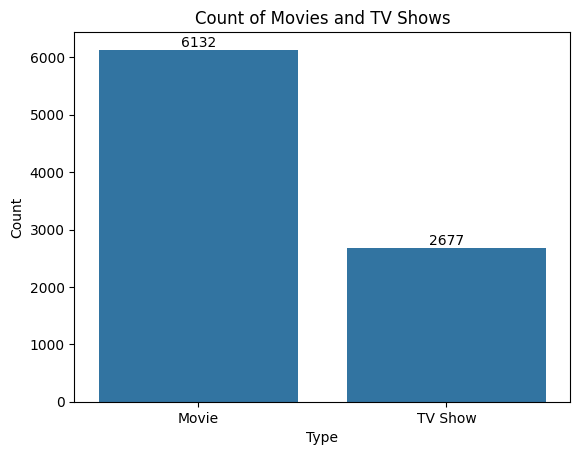

In [60]:
ax = sns.countplot(data=df, x='type')

ax.bar_label(ax.containers[0])

ax.set_xlabel('Type')
ax.set_ylabel('Count')
ax.set_title('Count of Movies and TV Shows')

plt.show()

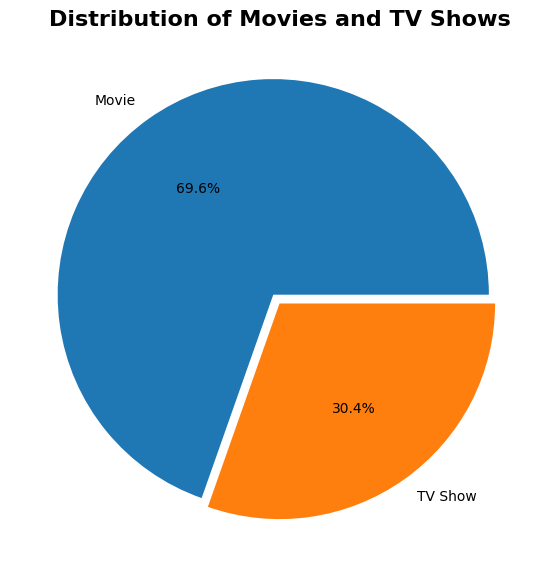

In [61]:
plt.figure(figsize=(7, 7))
gb = df.groupby('type').agg({'type':'count'})
gb

plt.pie(gb['type'], labels=gb.index, autopct='%1.1f%%', explode=[0.05,0])
plt.title('Distribution of Movies and TV Shows',fontsize=16,fontweight='bold')
plt.show()



Netflix's library is heavily skewed towards **Movies (69.6%)** compared to
**TV Shows (30.4%)**. This suggests Netflix has prioritised film content
over series, though TV shows drive higher engagement and watch time.

### 5.2 Top 10 Content-Producing Countries


/tmp/ipykernel_2564/424792200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


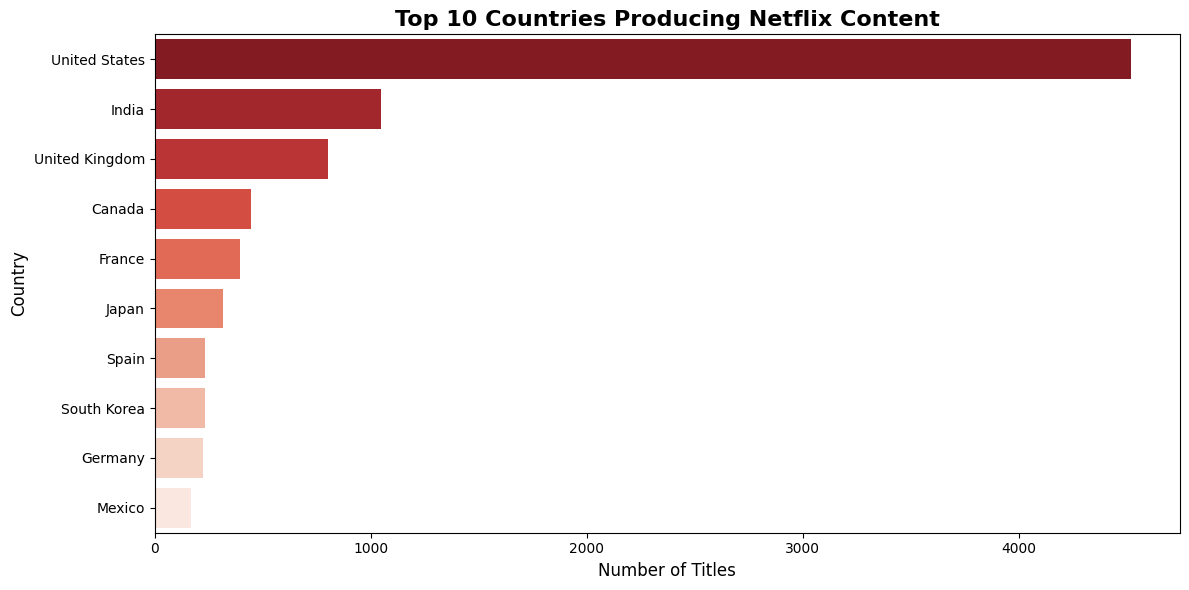

In [62]:
plt.figure(figsize=(12, 6))
countries = df['country'].str.split(', ').explode()
countries = countries[countries != 'Unknown']
top_countries = countries.value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()


The **United States dominates** with 4,521 titles — more than 4x the second
largest contributor. **India ranks 2nd** with 1,046 titles, reflecting
Netflix's significant investment in the Indian market. The **United Kingdom**
comes 3rd with 804 titles. Asian markets (Japan, South Korea) are also
prominently represented, showing Netflix's global content strategy.

### 5.3 Rating Distribution

/tmp/ipykernel_2564/2837963638.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Reds_r')


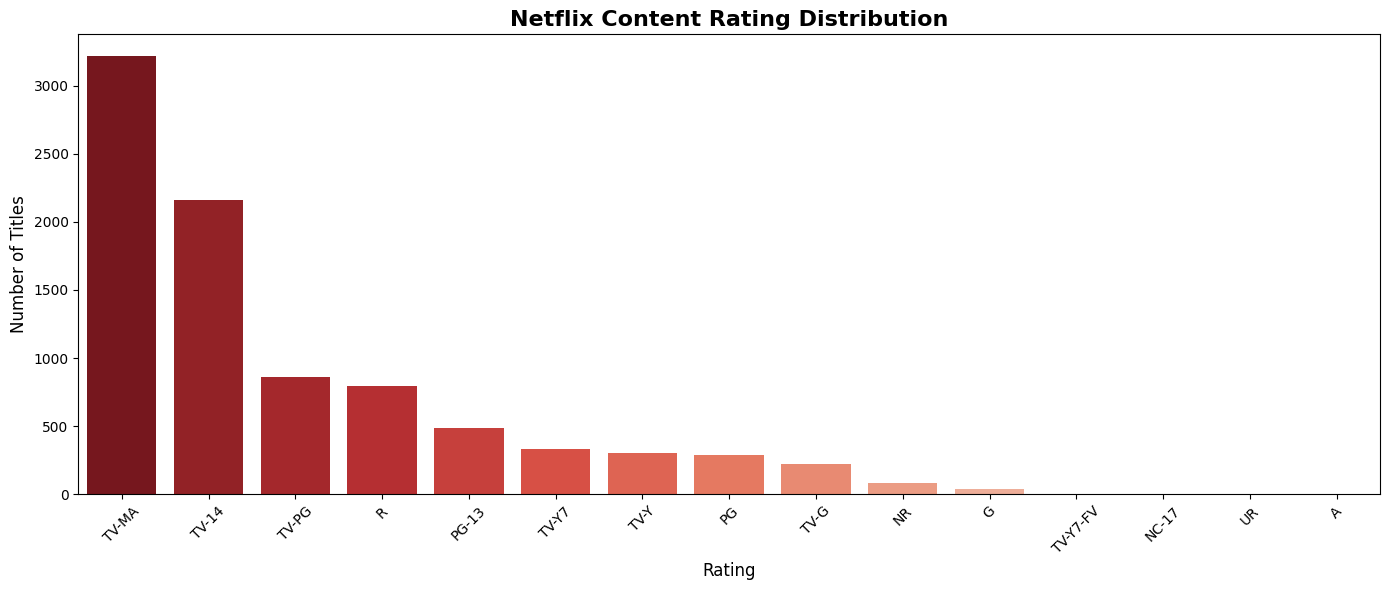

In [63]:
plt.figure(figsize=(14, 6))
rating_counts = df['rating'].value_counts()

sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Reds_r')
plt.title('Netflix Content Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**TV-MA (Mature Audience)** is the most common rating with 3,215 titles,
followed by **TV-14** with 2,160 titles. This shows Netflix primarily targets
**adult audiences** rather than family or children segments. Less than 15%
of content is rated G, PG, or TV-Y — confirming the platform's adult-first
content strategy.

### 5.4 Top 10 Genres

/tmp/ipykernel_2564/437828506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


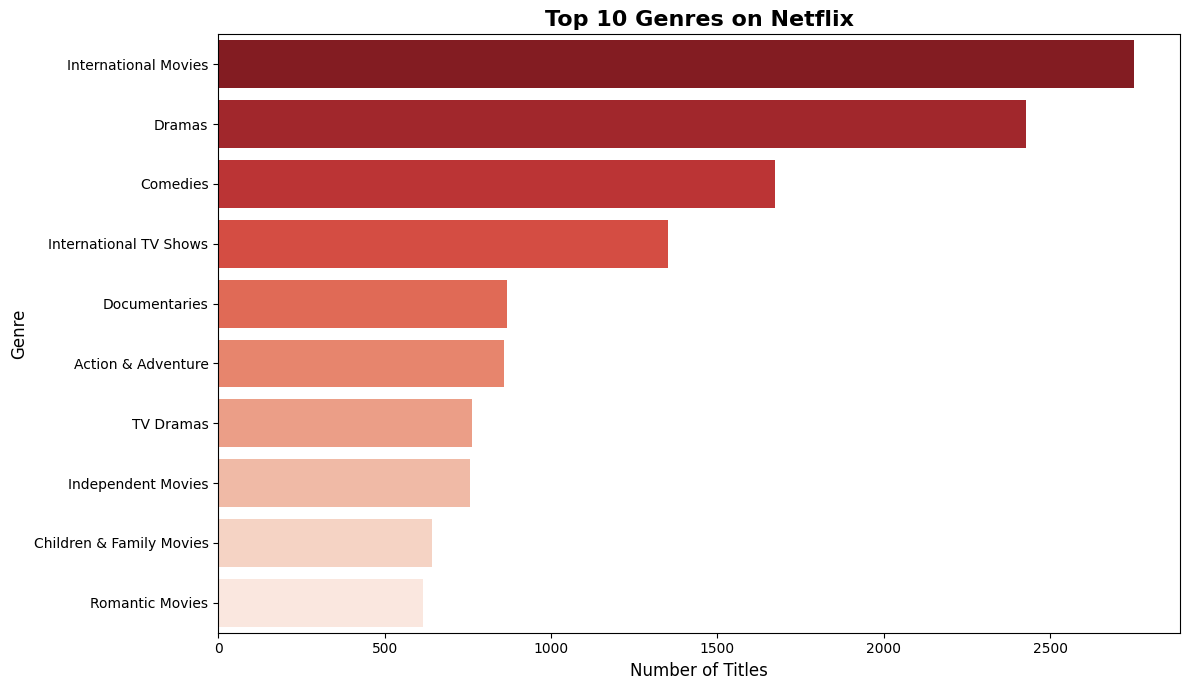

In [64]:
plt.figure(figsize=(12, 7))
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()


**International Movies** is the largest genre with 2,752 titles, confirming
Netflix's global content push. **Dramas (2,427)** and **Comedies (1,674)**
are the top English-language genres. The presence of **International TV Shows**
and **Documentaries** in the top 10 shows Netflix serves diverse audience tastes.

### 5.5 Movie Duration Distribution

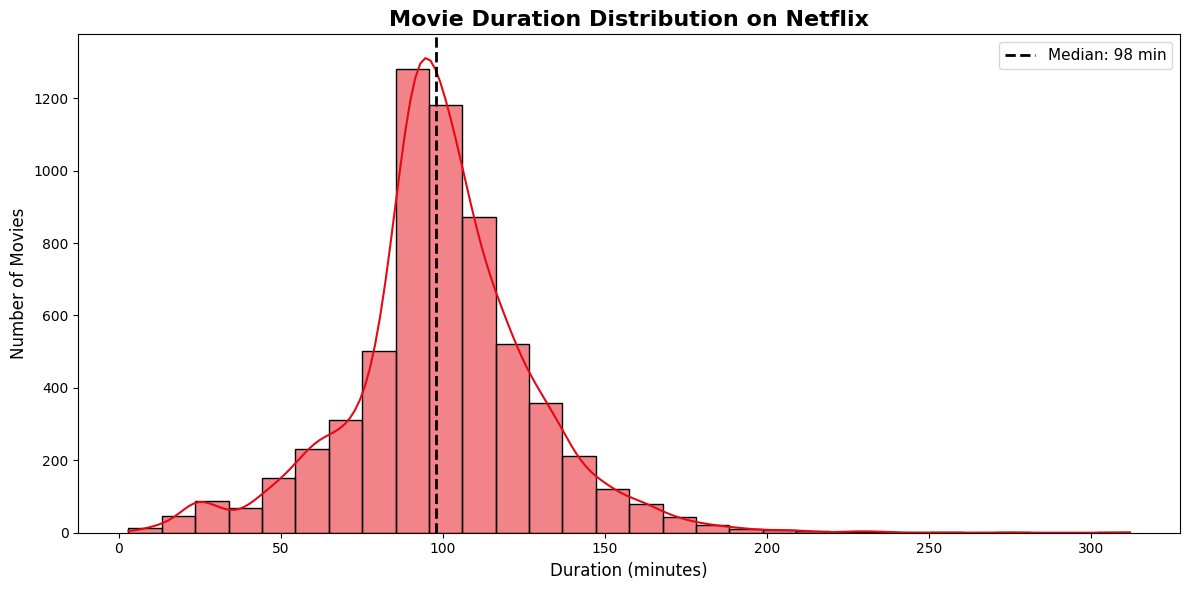

In [65]:
plt.figure(figsize=(12, 6))
movie_durations = df[df['type'] == 'Movie']['duration_value']

sns.histplot(movie_durations, bins=30, color='#E50914', kde=True)
plt.title('Movie Duration Distribution on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.axvline(movie_durations.median(), color='black',
            linestyle='--', linewidth=2,
            label=f'Median: {movie_durations.median():.0f} min')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


Movie durations follow a **near-normal distribution** with a median of
**98 minutes**. Most movies fall between **80 to 120 minutes** — the
standard feature film length. There are a small number of very short
(under 40 min) and very long (over 150 min) outliers, likely documentaries
or special productions.

### 5.6 TV Show Seasons Distribution

/tmp/ipykernel_2564/333087276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tv_seasons.index.astype(int), y=tv_seasons.values, palette='Reds_r')


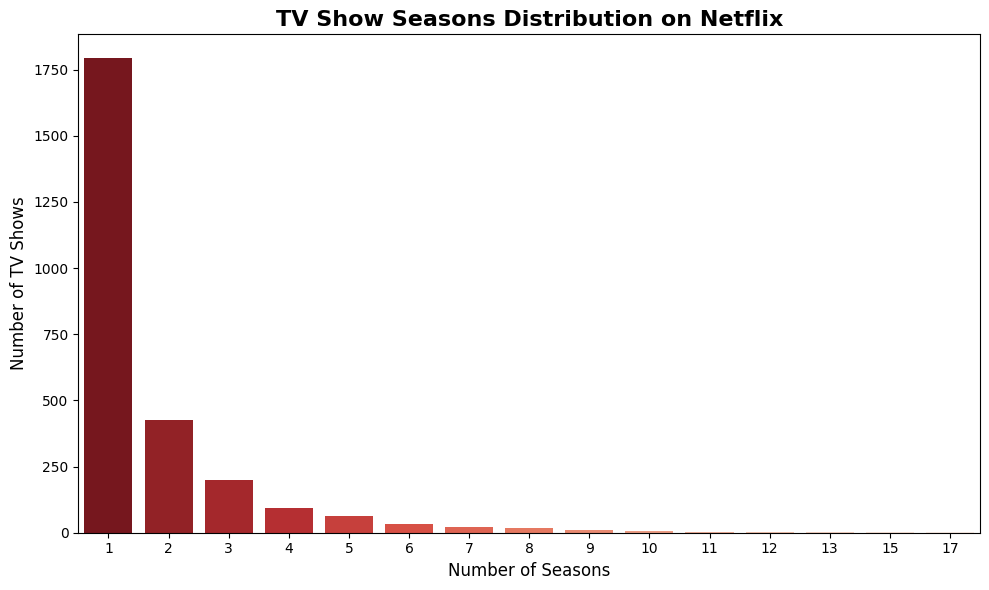

In [66]:
plt.figure(figsize=(10, 6))
tv_seasons = df[df['type'] == 'TV Show']['duration_value'].value_counts().sort_index()

sns.barplot(x=tv_seasons.index.astype(int), y=tv_seasons.values, palette='Reds_r')
plt.title('TV Show Seasons Distribution on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
plt.tight_layout()
plt.show()


An overwhelming **67% of TV Shows on Netflix have only 1 season** (1,794 shows).
Only 425 shows have 2 seasons and 199 have 3 seasons. This could indicate
Netflix's strategy of licensing international one-season shows, or that many
original series get cancelled after their first season.

### 5.7 Content Added Per Month — Heatmap

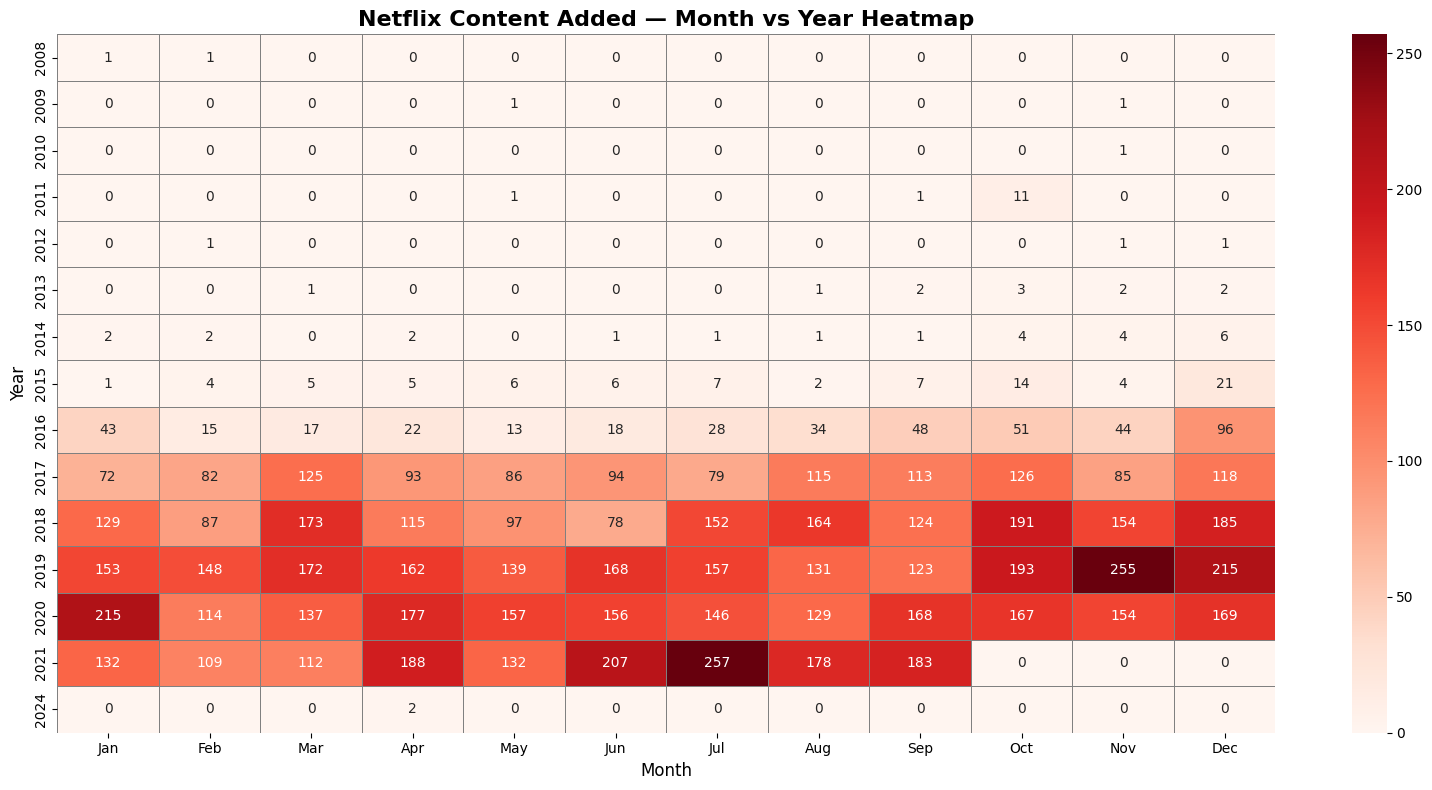

In [67]:
plt.figure(figsize=(16, 8))
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(heatmap_data, annot=True, fmt='d',
            cmap='Reds', linewidths=0.5, linecolor='gray')
plt.title('Netflix Content Added — Month vs Year Heatmap',
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()


Netflix adds content **consistently throughout the year** but certain months
show clear spikes. **July and December** tend to have higher additions — July
likely due to summer viewing demand and December due to holiday season.
The years **2018, 2019, and 2020** show the darkest cells, confirming the
peak content acquisition period. Early years (2008–2014) show very sparse
additions, confirming Netflix's streaming library was still being built.

### 5.8 Top 10 Directors

/tmp/ipykernel_2564/1275090188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='Reds_r')


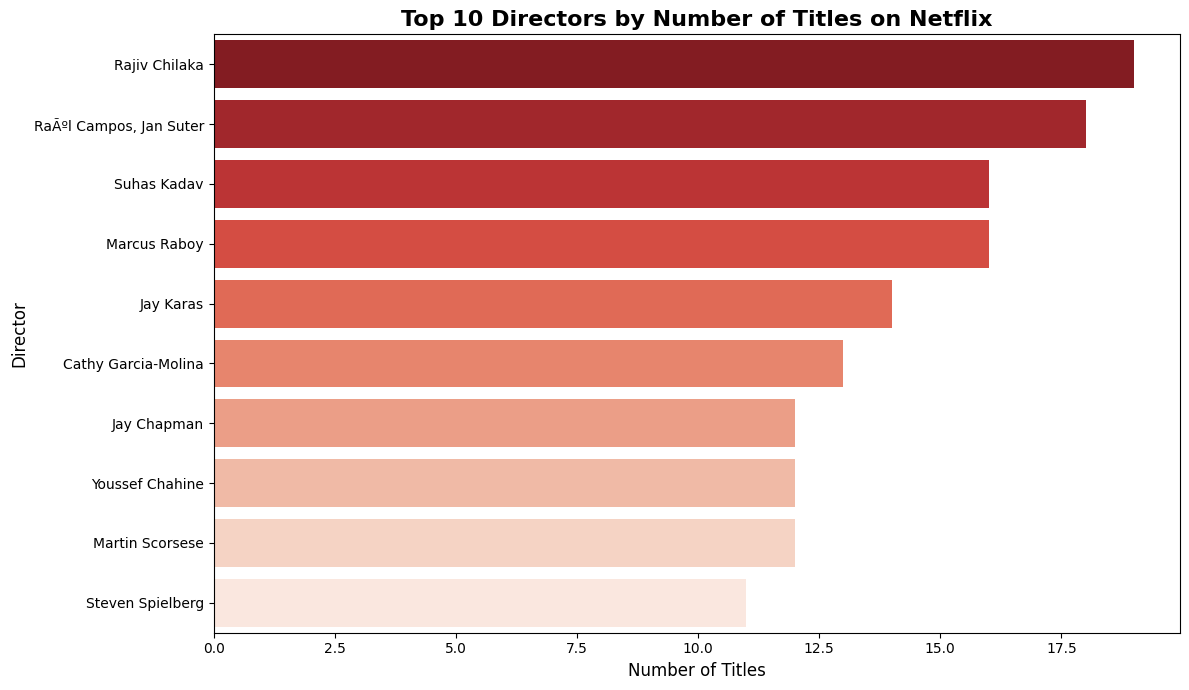

In [68]:
plt.figure(figsize=(12, 7))
directors = df[df['director'] != 'Unknown']['director']
top_directors = directors.value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index, palette='Reds_r')
plt.title('Top 10 Directors by Number of Titles on Netflix',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.tight_layout()
plt.show()


**Rajiv Chilaka** leads with 19 titles — he is the creator of the popular
Indian animated series *Chhota Bheem*, explaining the high count. The top
directors list reflects **Netflix's strong Indian content presence**, with
multiple Indian directors featured. This aligns with India being the 2nd
largest content contributor by country.

### 5.9 Top 10 Actors

/tmp/ipykernel_2564/3223715117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette='Reds_r')


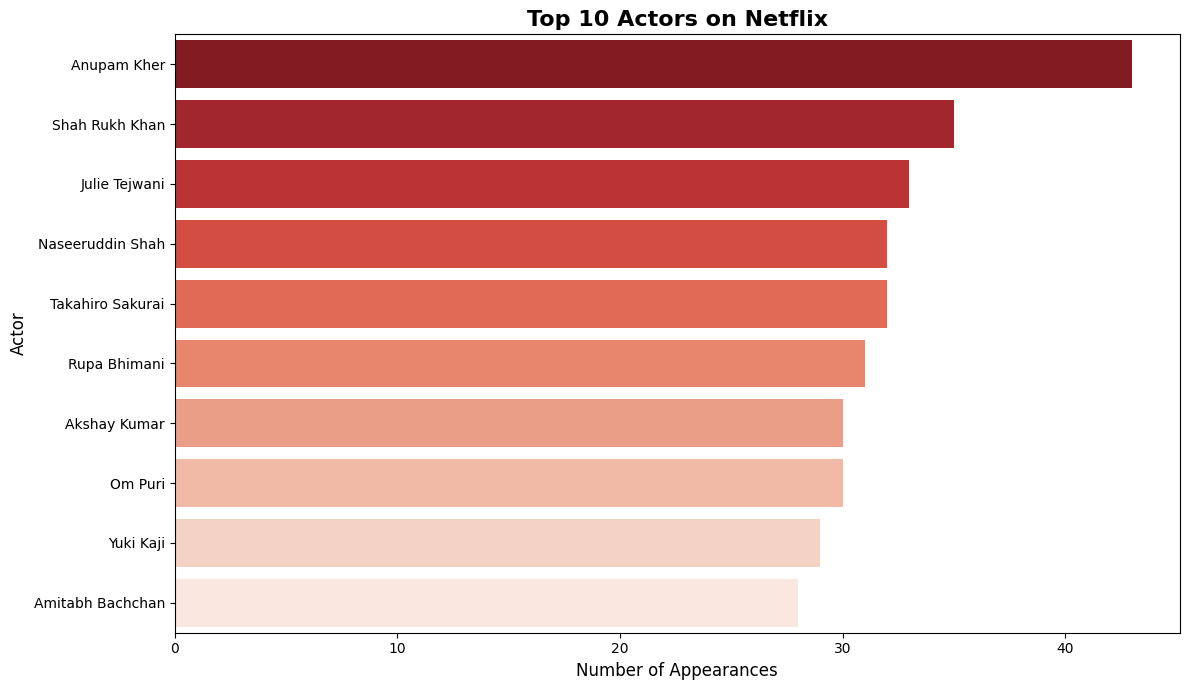

In [69]:
plt.figure(figsize=(12, 7))
actors = df['cast'].str.split(', ').explode()
actors = actors[actors != 'Unknown']
top_actors = actors.value_counts().head(10)

sns.barplot(x=top_actors.values, y=top_actors.index, palette='Reds_r')
plt.title('Top 10 Actors on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Appearances', fontsize=12)
plt.ylabel('Actor', fontsize=12)
plt.tight_layout()
plt.show()


**Anupam Kher** tops the list with 43 appearances, followed by
**Shah Rukh Khan (35)** and **Julie Tejwani (33)**. The dominance of
Indian actors in the top 10 again confirms Netflix's heavy investment
in Bollywood and Indian regional content to capture the massive Indian
subscriber base.

### 5.10  Movies vs TV Shows Growth Over Years

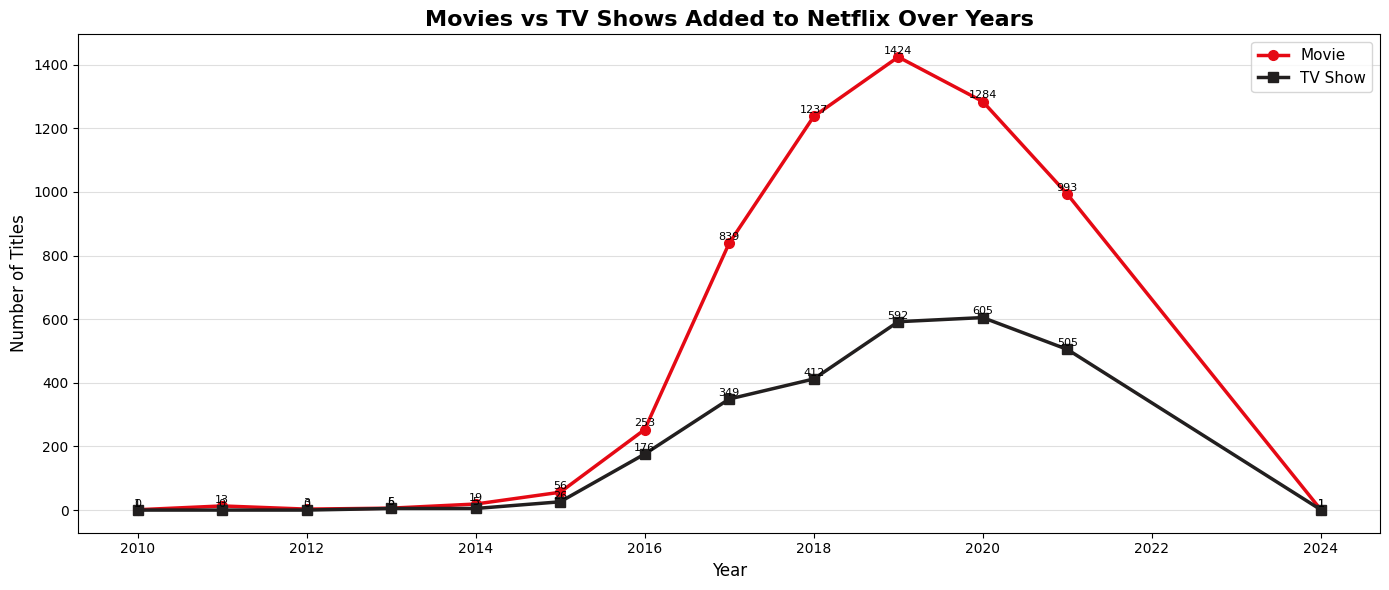

In [70]:
plt.figure(figsize=(14, 6))
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]  # cleaner view

for col, color, marker in zip(yearly.columns,
                               ['#E50914', '#221F1F'],
                               ['o', 's']):
    plt.plot(yearly.index, yearly[col],
             marker=marker, color=color,
             linewidth=2.5, label=col, markersize=7)
    for x, y in zip(yearly.index, yearly[col]):
        plt.text(x, y + 10, str(y), ha='center', fontsize=8)

plt.title('Movies vs TV Shows Added to Netflix Over Years',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


Both Movies and TV Shows grew rapidly from 2015 onwards. Movies consistently
outnumber TV Shows every year — the gap widened significantly during peak years
(2018–2020). TV Show additions grew proportionally faster in percentage terms,
suggesting Netflix was **gradually increasing its TV Show investment** even
while Movies dominated absolute numbers.

### 📈 Business Impact — TV Show Growth

The increasing trend of TV Shows suggests that Netflix should prioritize serialized content to improve customer retention and reduce churn rates.

### 5.11 Top 10 Countries — Movies vs TV Shows

<Figure size 1400x700 with 0 Axes>

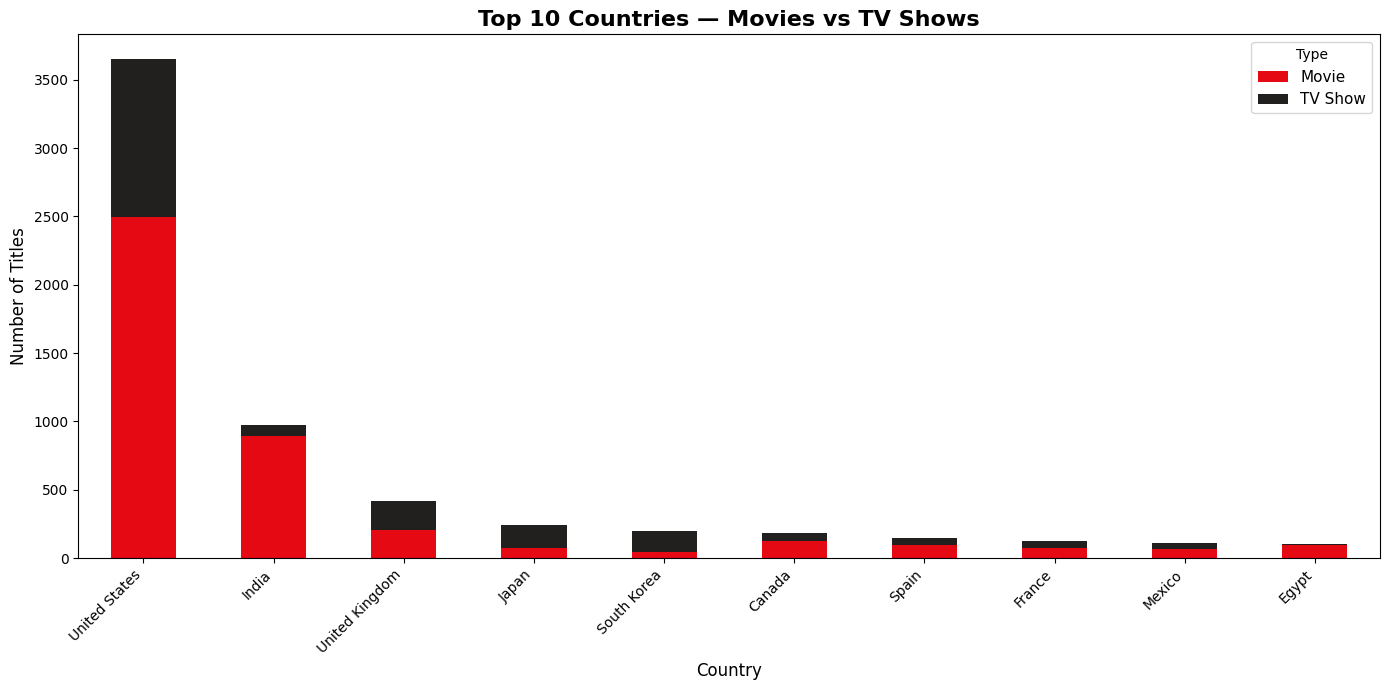

In [71]:
plt.figure(figsize=(14, 7))
country_type = df[df['country'] != 'Unknown'].groupby(
    ['country', 'type']).size().unstack(fill_value=0)
top10 = country_type.sum(axis=1).nlargest(10).index
country_type = country_type.loc[top10]

country_type.plot(kind='bar', stacked=True,
                  color=['#E50914', '#221F1F'],
                  figsize=(14, 7))
plt.title('Top 10 Countries — Movies vs TV Shows',
          fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type', fontsize=11)
plt.tight_layout()
plt.show()


The **United States** produces both Movies and TV Shows at scale — with a
roughly even split between the two. **India** almost exclusively contributes
Movies with very few TV Shows, reflecting the Bollywood-dominated Indian
content on the platform. **South Korea** shows the opposite trend —
higher TV Show contribution, driven by the global K-Drama phenomenon.

### 5.12 Country vs Genre Heatmap

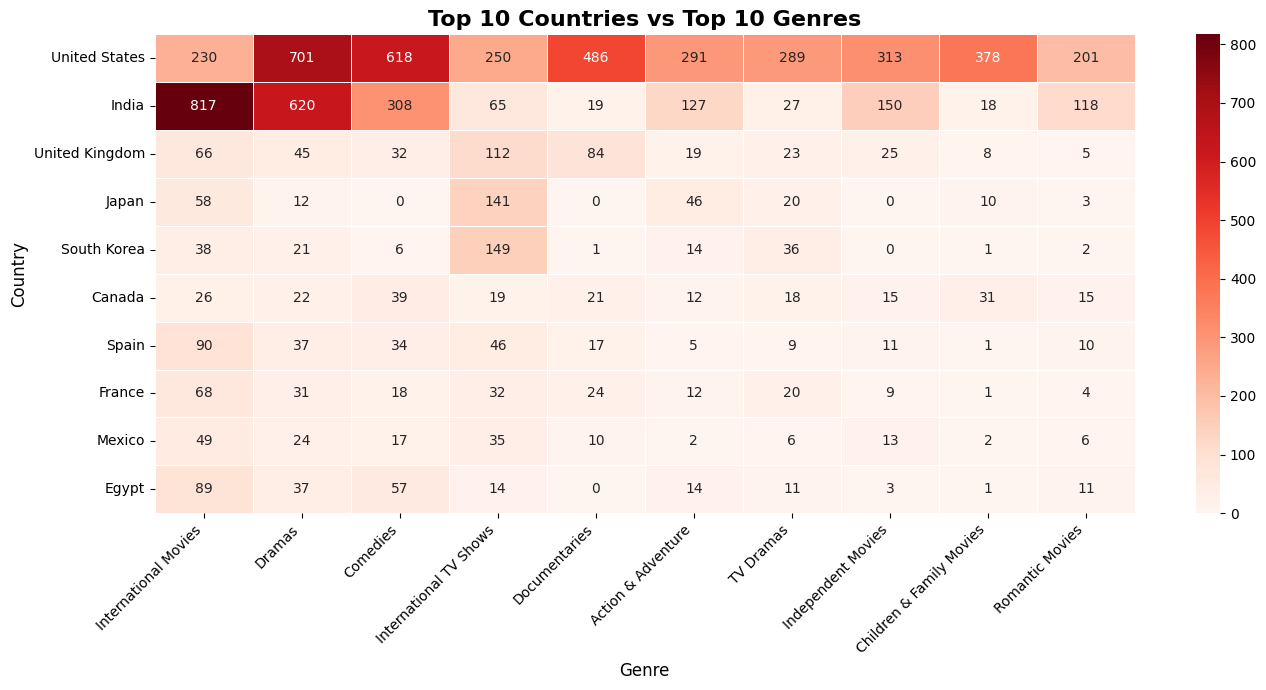

In [72]:
# Explode multi-genre column, then crosstab with top countries
genres_exploded = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
heatmap_data = pd.crosstab(genres_exploded['country'], genres_exploded['genre'])

top_countries = df['country'].value_counts().head(10).index
top_genres = genres_exploded['genre'].value_counts().head(10).index

heatmap_data = heatmap_data.loc[top_countries, top_genres]

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.5, annot=True, fmt='d')
plt.title('Top 10 Countries vs Top 10 Genres', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The distribution of content across countries highlights clear regional preferences. India shows a strong dominance in Movies and Drama, while South Korea is heavily focused on TV Shows, particularly in serialized formats. The United States maintains a balanced mix of content types. This pattern suggests that Netflix adopts a localized content strategy, tailoring its offerings based on regional audience behavior and cultural preferences to maximize engagement.

### 🌍 Business Impact — Regional Content Strategy

Regional variation in content preferences indicates that Netflix should continue investing in localized content production to strengthen its global market position.

### 5.13 Duration Distribution by Content Type

/tmp/ipykernel_2564/2295788653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='duration_value', data=df,


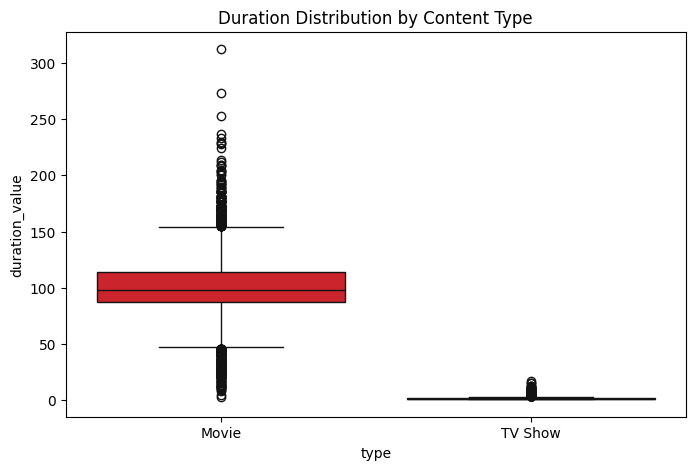

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='duration_value', data=df,
            palette={'Movie': '#E50914', 'TV Show': '#221F1F'})
plt.title('Duration Distribution by Content Type')
plt.show()

Movies exhibit a relatively consistent duration range, typically between 80–120 minutes, aligning with standard industry formats. In contrast, TV Shows display significantly higher variability due to differences in seasons and episode structures. This indicates that while Movies follow a standardized format, TV Shows provide flexible storytelling opportunities, allowing Netflix to experiment with diverse content formats to enhance viewer engagement.

### 5.14 Content Rating Distribution by Type

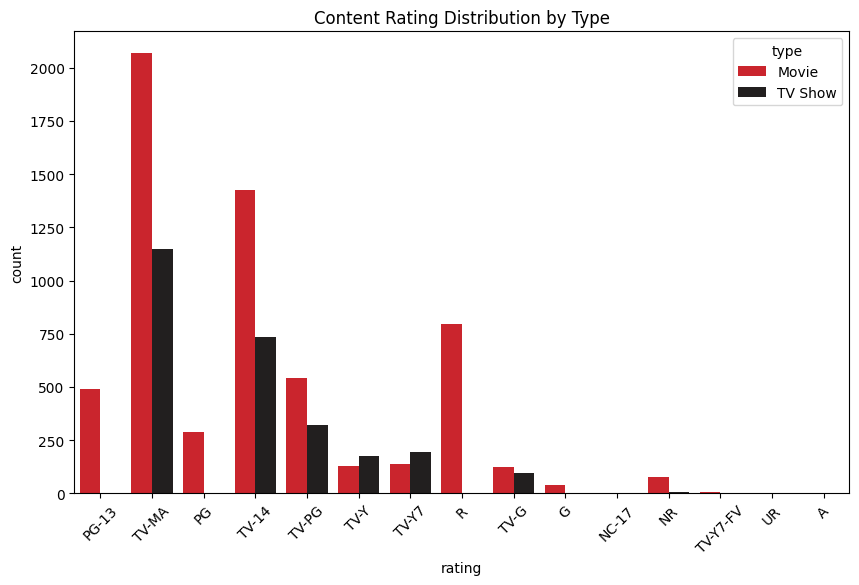

In [77]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='rating', hue='type',
              palette={'Movie': '#E50914', 'TV Show': '#221F1F'})
plt.xticks(rotation=45)
plt.title('Content Rating Distribution by Type')
plt.show()

Content ratings are heavily concentrated in TV-MA and TV-14 categories, especially for TV Shows. This indicates that Netflix primarily targets mature audiences with content designed for binge-watching. The relatively lower proportion of family and children’s content suggests a strategic focus on adult viewers, who are more likely to engage deeply and spend more time on the platform.

### 5.15 Content Clustering — KMeans Analysis

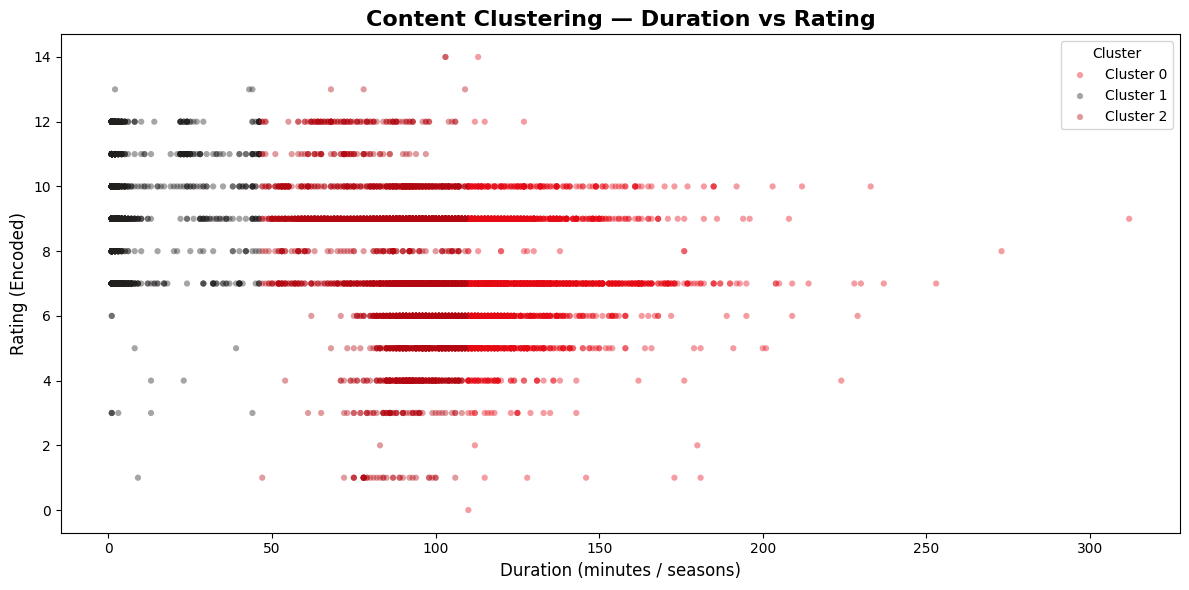

In [79]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

# Use 'duration_value' which is numeric, instead of 'duration_unit'
df_cluster = df[['type', 'rating', 'duration_value']].dropna().copy()

le = LabelEncoder()
df_cluster['type'] = le.fit_transform(df_cluster['type'])
df_cluster['rating'] = le.fit_transform(df_cluster['rating'])

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_cluster['cluster'] = kmeans.fit_predict(df_cluster)

# plt.figure(figsize=(8,6))
# # Use 'duration_value' for the scatter plot as well
# sns.scatterplot(x='duration_value', y='rating', hue='cluster', data=df_cluster)
# plt.title('Content Clustering Based on Duration and Rating')
# plt.show()

plt.figure(figsize=(12, 6))

cluster_colors = {0: '#E50914', 1: '#221F1F', 2: '#B20710'}

for cluster_id, color in cluster_colors.items():
    subset = df_cluster[df_cluster['cluster'] == cluster_id]
    plt.scatter(subset['duration_value'], subset['rating'],
                c=color, label=f'Cluster {cluster_id}',
                alpha=0.4, edgecolors='none', s=20)

plt.title('Content Clustering — Duration vs Rating', fontsize=16, fontweight='bold')
plt.xlabel('Duration (minutes / seasons)', fontsize=12)
plt.ylabel('Rating (Encoded)', fontsize=12)
plt.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.show()

In [81]:
# Cluster profile summary
cluster_summary = df_cluster.groupby('cluster').agg(
    count=('duration_value', 'count'),
    avg_duration=('duration_value', 'mean'),
    avg_rating=('rating', 'mean')
).round(2)

print(cluster_summary)

         count  avg_duration  avg_rating
cluster                                 
0         1893        130.05        7.26
1         2926          4.27        8.95
2         3990         89.39        7.70


- Cluster 0 → Short duration, lower rating → Casual / kids content  
- Cluster 1 → Medium duration, high rating → Core adult movies  
- Cluster 2 → Long duration, high rating → Premium binge-worthy series

Clustering analysis reveals distinct segments of content based on duration and rating. Certain clusters represent short-duration, lower-rated content, likely targeting casual viewers, while others represent long-duration, high-maturity content designed for deep engagement. This segmentation suggests that Netflix strategically diversifies its content portfolio to cater to different audience segments, balancing both accessibility and premium viewing experiences.

#  Key Takeaways

1. Netflix is gradually shifting from Movies to TV Shows, indicating a focus on long-term user engagement rather than one-time content consumption.

2. The platform has aggressively expanded into international markets, with significant content contributions from India, South Korea, and other regions.

3. Content preferences vary by region, showing that Netflix adopts a localized content strategy to maximize audience engagement.

4. The majority of content is targeted toward mature audiences, highlighting Netflix’s focus on adult viewers.

5. While Movies dominate in quantity, TV Shows are growing faster, suggesting a strategic balance between scale and retention.

#  Strategic Recommendations

1. Increase investment in multi-season TV Shows to improve long-term user retention  
2. Expand content production in emerging markets beyond India to reduce dependency on specific regions  
3. Strengthen children and family-oriented content to diversify the audience base  
4. Focus on high-performing genres such as Drama and International content to maximize engagement  
5. Maintain a balance between Movies (for scale) and TV Shows (for retention) to ensure sustainable growth

#  Conclusion

Netflix’s content strategy reflects a balance between global expansion and localized storytelling. While Movies dominate in quantity, the increasing focus on TV Shows highlights a shift toward engagement-driven growth. The platform’s emphasis on mature audiences and international content suggests a data-driven approach to maximizing viewer retention and market reach. Moving forward, strategic investments in multi-season content and regional diversification will be key to sustaining long-term growth.